# Trabajo Práctico Final: Predicción de Deserción y Éxito Académico

## 1. Elicitación de Requerimientos y Procesos de Negocio

El presente proyecto se centra en la optimización de los procesos de negocio vinculados a la gestión, seguimiento y retención estudiantil de una institución. La deserción no solo representa un quiebre en la trayectoria académica de un alumno, sino que afecta directamente la planificación administrativa y financiera.

A través de la elicitación de requerimientos estructurada para este sistema, definimos que el área académica necesita una herramienta predictiva precisa y accionable. Por ello, el requerimiento central del negocio establece:

Alcance del Modelo: Desarrollar un modelo de clasificación binaria estricto (Graduado vs. Desertor). Se excluye el estado ambiguo "Matriculado" para generar fronteras de decisión matemáticas más limpias.

Regla de Negocio y Accionabilidad: Identificar de forma temprana a los estudiantes en riesgo para que el área de tutorías pueda activar protocolos de intervención basados en las variables predictivas más críticas (estado de cuotas, becas y rendimiento del primer cuatrimestre).

## 1. importacion de librerias y carga del dataset.

In [64]:
# Importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')


In [65]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [66]:
# Reemplazamos espacios por guiones bajos y eliminamos los paréntesis
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

## 2. Integridad de los datos (valores nulos)

- El dataset obtenido de la página de Kanggle es totalmente integro y no requiere ningun tipo de imputacion.

In [67]:
print("Valores nulos totales en el dataset:", df.isnull().sum().sum())

Valores nulos totales en el dataset: 0


## 3. Transformación y Codificación de la Variable Objetivo 

El dataset original presenta un problema de clasificación multiclase que incluye la categoría "Enrolled" (Matriculado). Este estado representa un período de transición ambiguo; sus datos históricos se superponen constantemente tanto con el perfil de los que abandonan como con los que se gradúan, lo que introduce "ruido" al modelo. Al filtrar y excluir esta clase, reducimos el alcance a un modelo de clasificación binaria estricta (éxito vs. fracaso). Esto permite que los algoritmos establezcan fronteras matemáticas mucho más claras y maximicen sus métricas de precisión.

In [68]:
# 3. Filtrar para clasificación binaria: Nos quedamos solo con Graduate y Dropout
df_clean = df[df['Target'].isin(['Graduate', 'Dropout'])].copy()

Los algoritmos de Machine Learning de la librería scikit-learn (como los Árboles de Decisión y Bosques Aleatorios) requieren que todas las variables de entrada y salida sean estrictamente numéricas para poder procesar las ecuaciones internas. No pueden interpretar etiquetas de texto crudo.


In [69]:
# 4. Codificar la variable objetivo a valores numéricos (1 = Dropout, 0 = Graduate)
df_clean['Target'] = df_clean['Target'].map({'Dropout': 1, 'Graduate': 0})

In [70]:
print(f"Tamaño del dataset original: {df.shape}")
print(f"Tamaño del dataset para modelado: {df_clean.shape}")

Tamaño del dataset original: (4424, 35)
Tamaño del dataset para modelado: (3630, 35)


# Análisis Exploratorio de Datos

### Análisis de Impacto Financiero en la Retención Estudiantil

Esta visualización cruza la variable financiera relacionada al pago de cuotas con el estado académico final del estudiante. Desde la perspectiva de los procesos de negocio y la gestión de la retención estudiantil, el análisis revela dos patrones críticos:

* **Morosidad como Alerta Crítica:** La cohorte de estudiantes que registra deudas activas (valor 0) presenta una tasa de deserción casi absoluta. Esto convierte a la variable financiera en un nodo de decisión primario para el algoritmo.
* **Limitación de la Variable Aislada:** Si bien mantener las cuotas al día (valor 1) es la condición prevalente entre los estudiantes que logran graduarse, una proporción significativa de este grupo también finaliza en deserción. Esta varianza justifica técnicamente la implementación de un modelo de Machine Learning multivariable; una regla de negocio simple y unidimensional omitiría la detección de un volumen crítico de estudiantes en riesgo.

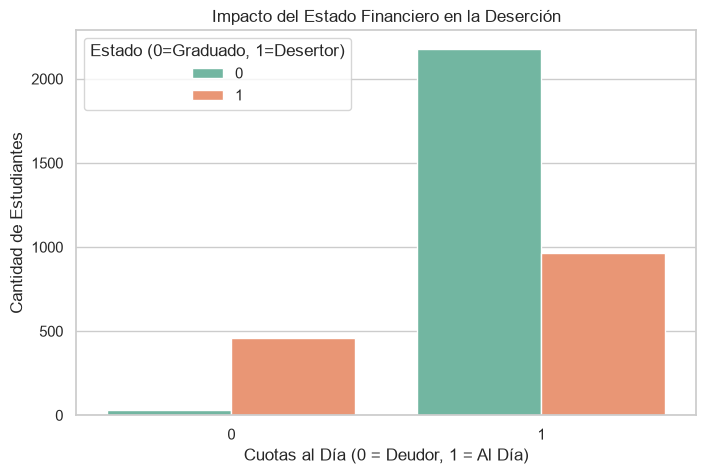

In [71]:

# estilo visual de los graficos
sns.set_theme(style="whitegrid")

# visualizacion 1: Proceso de Negocio Financiero
# grafico de barras para ver la relacion entre estar al día con las cuotas y la desercion
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='Tuition_fees_up_to_date', hue='Target', palette='Set2')
plt.title('Impacto del Estado Financiero en la Deserción')
plt.xlabel('Cuotas al Día (0 = Deudor, 1 = Al Día)')
plt.ylabel('Cantidad de Estudiantes')
plt.legend(title='Estado (0=Graduado, 1=Desertor)')
plt.show()


### Distribución del Rendimiento Académico Temprano

Este diagrama de caja evalúa el comportamiento de las calificaciones promedio obtenidas durante el primer semestre, funcionando como un indicador temprano de éxito o fracaso académico.

* **Consistencia en Graduados:** El rango intercuartílico (el 50% central de los datos representados en la caja) de los estudiantes que logran el título expone una alta consistencia, concentrando sus promedios en una franja estrecha y superior.
* **Dispersión y Abandono en Desertores:** La población que deserta no solo registra una mediana académica inferior, sino que presenta una extrema dispersión de datos hacia el límite inferior de la escala (nota 0). Esto evidencia que la deserción formal está precedida, en gran medida, por un cese temprano en la participación de las instancias de evaluación. El modelo predictivo deberá ponderar este bajo rendimiento inicial como un factor de alto riesgo.

C:\Users\facun\AppData\Local\Temp\ipykernel_18372\515743561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Target', y='Curricular_units_1st_sem_grade', palette='pastel')


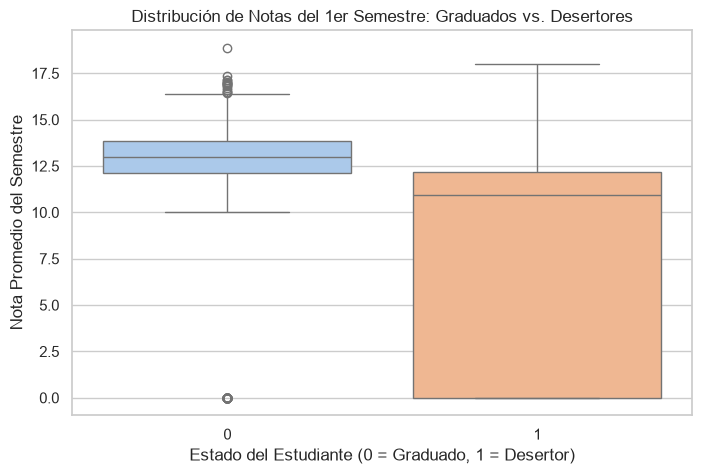

In [72]:
# Visualizacion 2: Rendimiento Academico Temprano
# Diagrama de caja (Boxplot) para comparar las notas del primer semestre
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Target', y='Curricular_units_1st_sem_grade', palette='pastel')
plt.title('Distribución de Notas del 1er Semestre: Graduados vs. Desertores')
plt.xlabel('Estado del Estudiante (0 = Graduado, 1 = Desertor)')
plt.ylabel('Nota Promedio del Semestre')
plt.show()

# Separación de Datos y Entrenamiento del Modelo

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as pl

In [74]:
# 1. definimos las variables predictoras (X) y la variable objetivo (y)
# utilizamos las características seleccionadas para la API
features = [
    'Marital_status', 'Course', 'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'Age_at_enrollment', 'Debtor',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade'
]

X = df_clean[features]
y = df_clean['Target']

In [75]:
# 2. Dividimos el dataset: 80% para entrenamiento, 20% para prueba
# Usamos stratify=y para asegurar que la proporcion de desertores se mantenga en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
# 3. Inicializar y entrenar el Árbol de Decisión
# limitamos la profundidad para poder visualizarlo
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [77]:
# 4. Realizar predicciones con los datos de prueba
y_pred_tree = tree_model.predict(X_test)

In [78]:
# 5. Evaluar el modelo
print(f"Precision General: {accuracy_score(y_test, y_pred_tree):.2f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_tree, target_names=['Graduado (0)', 'Desertor (1)']))

Precision General: 0.90

Reporte de Clasificación:
              precision    recall  f1-score   support

Graduado (0)       0.87      0.97      0.92       442
Desertor (1)       0.94      0.78      0.86       284

    accuracy                           0.90       726
   macro avg       0.91      0.88      0.89       726
weighted avg       0.90      0.90      0.89       726



## Visualización de las Reglas de Negocio

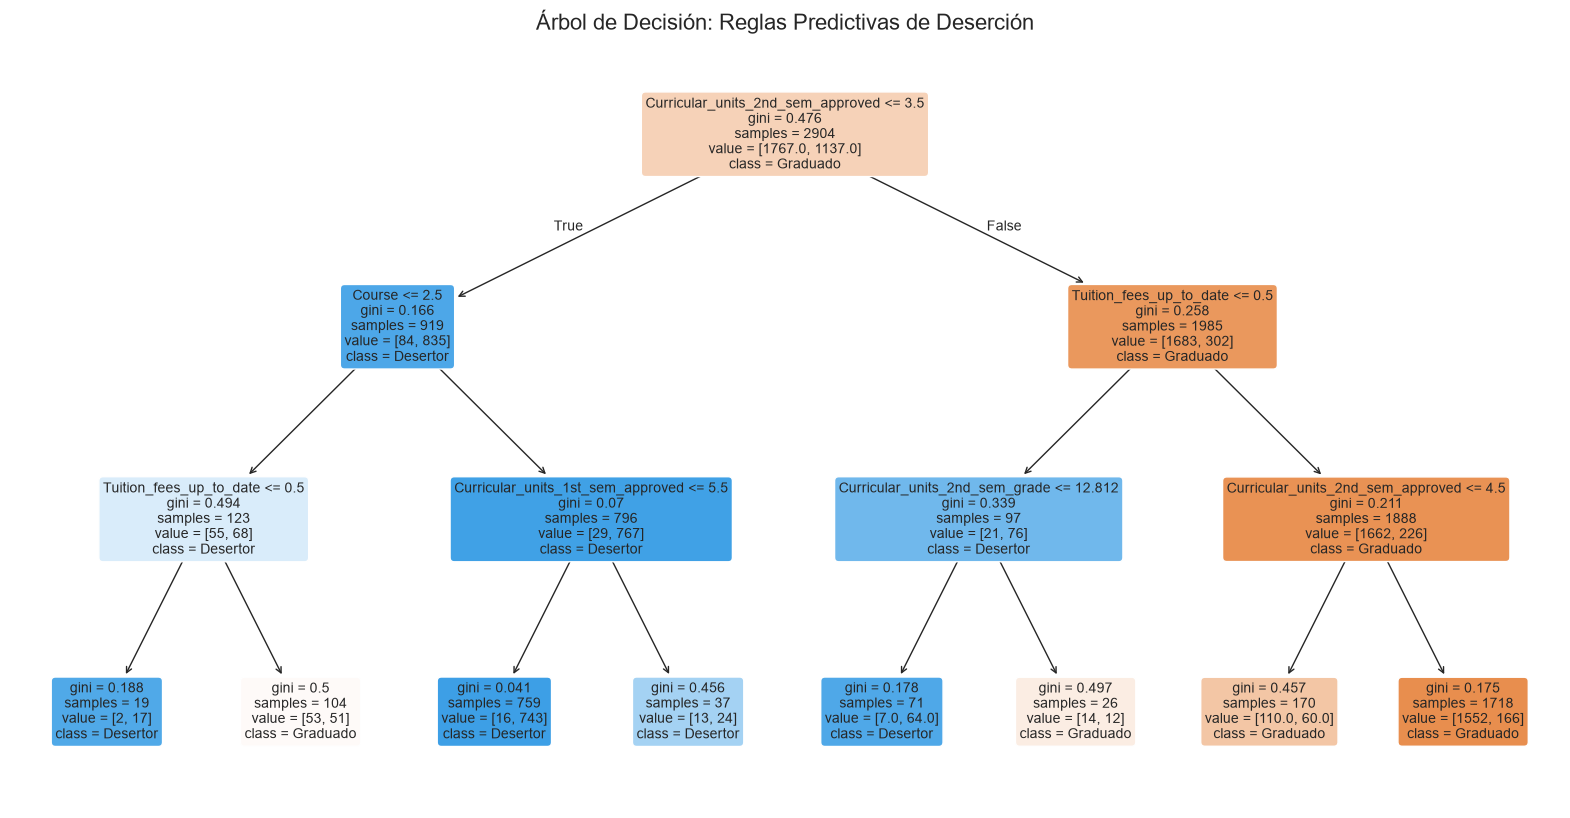

In [79]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=features, 
          class_names=['Graduado', 'Desertor'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Árbol de Decisión: Reglas Predictivas de Deserción", fontsize=16)
plt.show()

### Entrenamiento y Evaluación del Modelo Base (Decision Tree)

Para establecer nuestra línea base de predicción, implementamos un algoritmo de Árbol de Decisión (`DecisionTreeClassifier`). 

* **Prevención de Sobreajuste (Overfitting):** Se configuró el hiperparámetro `max_depth=3`. Al limitar la profundidad del árbol, evitamos que el modelo memorice los datos de entrenamiento, forzándolo a encontrar patrones generales y robustos que funcionen bien en el mundo real.
* **Métricas de Negocio:** El reporte de clasificación nos permite observar no solo la precisión global (Accuracy), sino métricas críticas como el *Recall* para la clase "Desertor (1)". En un contexto educativo, maximizar el Recall es vital, ya que el costo de no detectar a un alumno en riesgo (falso negativo) es mucho mayor que el de contactar preventivamente a un alumno que estaba bien (falso positivo).

# Entrenamiento del Bosque Aleatorio (Random Forest)

Entrenamiento del Modelo Final y Exportación

In [80]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

In [81]:
# 1. inicializar el modelo de ensamble
#utilizamos class_weight='balanced' para forzar al algoritmo a prestar más atención a la clase minoritaria (Desertores)
rf_model = RandomForestClassifier(
    n_estimators=100,      # Cantidad de árboles en el bosque
    max_depth=5,           # Profundidad máxima para prevenir sobreajuste
    random_state=42, 
    class_weight='balanced' 
)

In [82]:
# 2. entrenar el modelo con los mismos datos
rf_model.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

In [83]:
# 4.evaluar el nuevo modelo
print("--- Rendimiento del Bosque Aleatorio ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred_rf):.2f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['Graduado (0)', 'Desertor (1)']))

--- Rendimiento del Bosque Aleatorio ---
Precisión General (Accuracy): 0.89

Reporte de Clasificación:
              precision    recall  f1-score   support

Graduado (0)       0.92      0.90      0.91       442
Desertor (1)       0.85      0.88      0.87       284

    accuracy                           0.89       726
   macro avg       0.89      0.89      0.89       726
weighted avg       0.89      0.89      0.89       726



### Exportación del Modelo para el Backend

In [84]:
#crear la carpeta 'models' en el directorio superior si no existe
os.makedirs('../models', exist_ok=True)

In [85]:
# Definir la ruta del archivo y exportar con joblib
ruta_modelo = '../models/modelo_estudiantes.pkl'
joblib.dump(rf_model, ruta_modelo)

print(f"\nProceso finalizado. Modelo exportado exitosamente en: {ruta_modelo}")


Proceso finalizado. Modelo exportado exitosamente en: ../models/modelo_estudiantes.pkl
